# Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

df = pd.read_csv('../ml/df_model.csv', sep=';', dtype={'Code_INSEE': str})
display(df.head(5))

,Code_INSEE,Résultat,Femmes,Hommes,Agriculteurs,Artisans,Cadres,Intermédiaires,Employés,Ouvriers,...,55-64 ans,65-79 ans,80 ans et +,Mariés,Pacsés,Concubinage,Veufs,Divorcés,Célibataires,Population_active
0,01001,droite,47.184259,52.113958,0.704243,5.633941,10.563640,14.789096,15.493339,17.606067,...,18.794835,18.364419,6.312769,51.219512,7.890961,16.499283,5.882353,3.156385,15.351506,697.000000
1,01002,gauche,41.363637,50.555556,11.489899,2.297980,9.191919,13.787879,9.191919,9.191919,...,12.037037,14.814815,8.333333,47.685185,11.111111,9.722222,3.240741,7.407407,20.833333,216.000000
2,01004,droite,52.881826,47.118174,0.127297,3.114317,7.806622,15.437689,17.760558,15.886919,...,14.436934,16.198957,6.106620,40.957640,5.835323,9.955739,6.778822,8.566899,27.644693,12594.508695
3,01005,droite,51.346262,47.882309,0.362612,6.556032,8.691036,15.289281,21.150485,13.928360,...,17.295346,15.384787,5.562916,48.809515,7.840915,14.193995,4.623646,4.509098,20.022831,1554.355560
4,01006,droite,39.860139,54.807692,0.000000,0.000000,0.000000,9.965035,14.947553,44.842658,...,23.076923,25.000000,5.769231,49.038462,8.653846,10.576923,2.884615,9.615385,19.230769,104.000000


# Analyses univariées

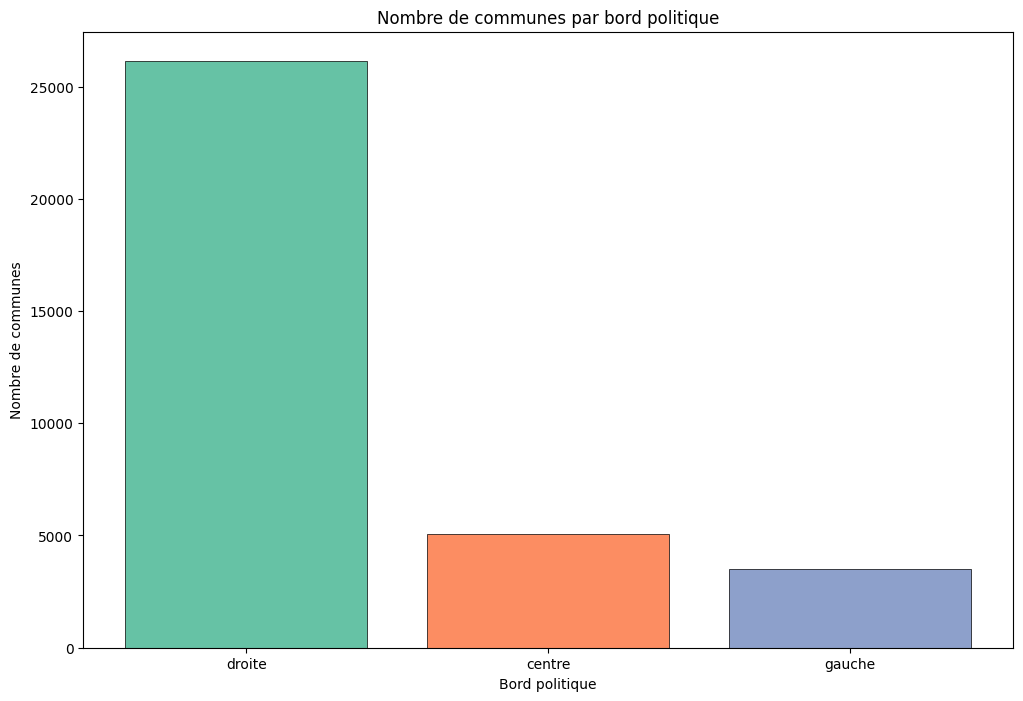

In [3]:
counts = df['Résultat'].value_counts()

plt.bar(range(len(counts)), counts.values, color=sns.color_palette("Set2", len(counts)), edgecolor='black', linewidth=0.5)
plt.title('Nombre de communes par bord politique')
plt.xlabel('Bord politique')
plt.ylabel('Nombre de communes')
plt.xticks(range(len(counts)), labels=counts.index)
plt.show()

La droite est beaucoup plus représentée que le centre et la gauche, il faudra tenir compte de ce déséquilibre pour le modèle

__Il faudra aussi hiérarchiser gauche-droite-centre dans le modèle, avec le centre au milieu, au lieu de faire un LabelEncoding sans hiérarchie__

# Matrice de corrélations

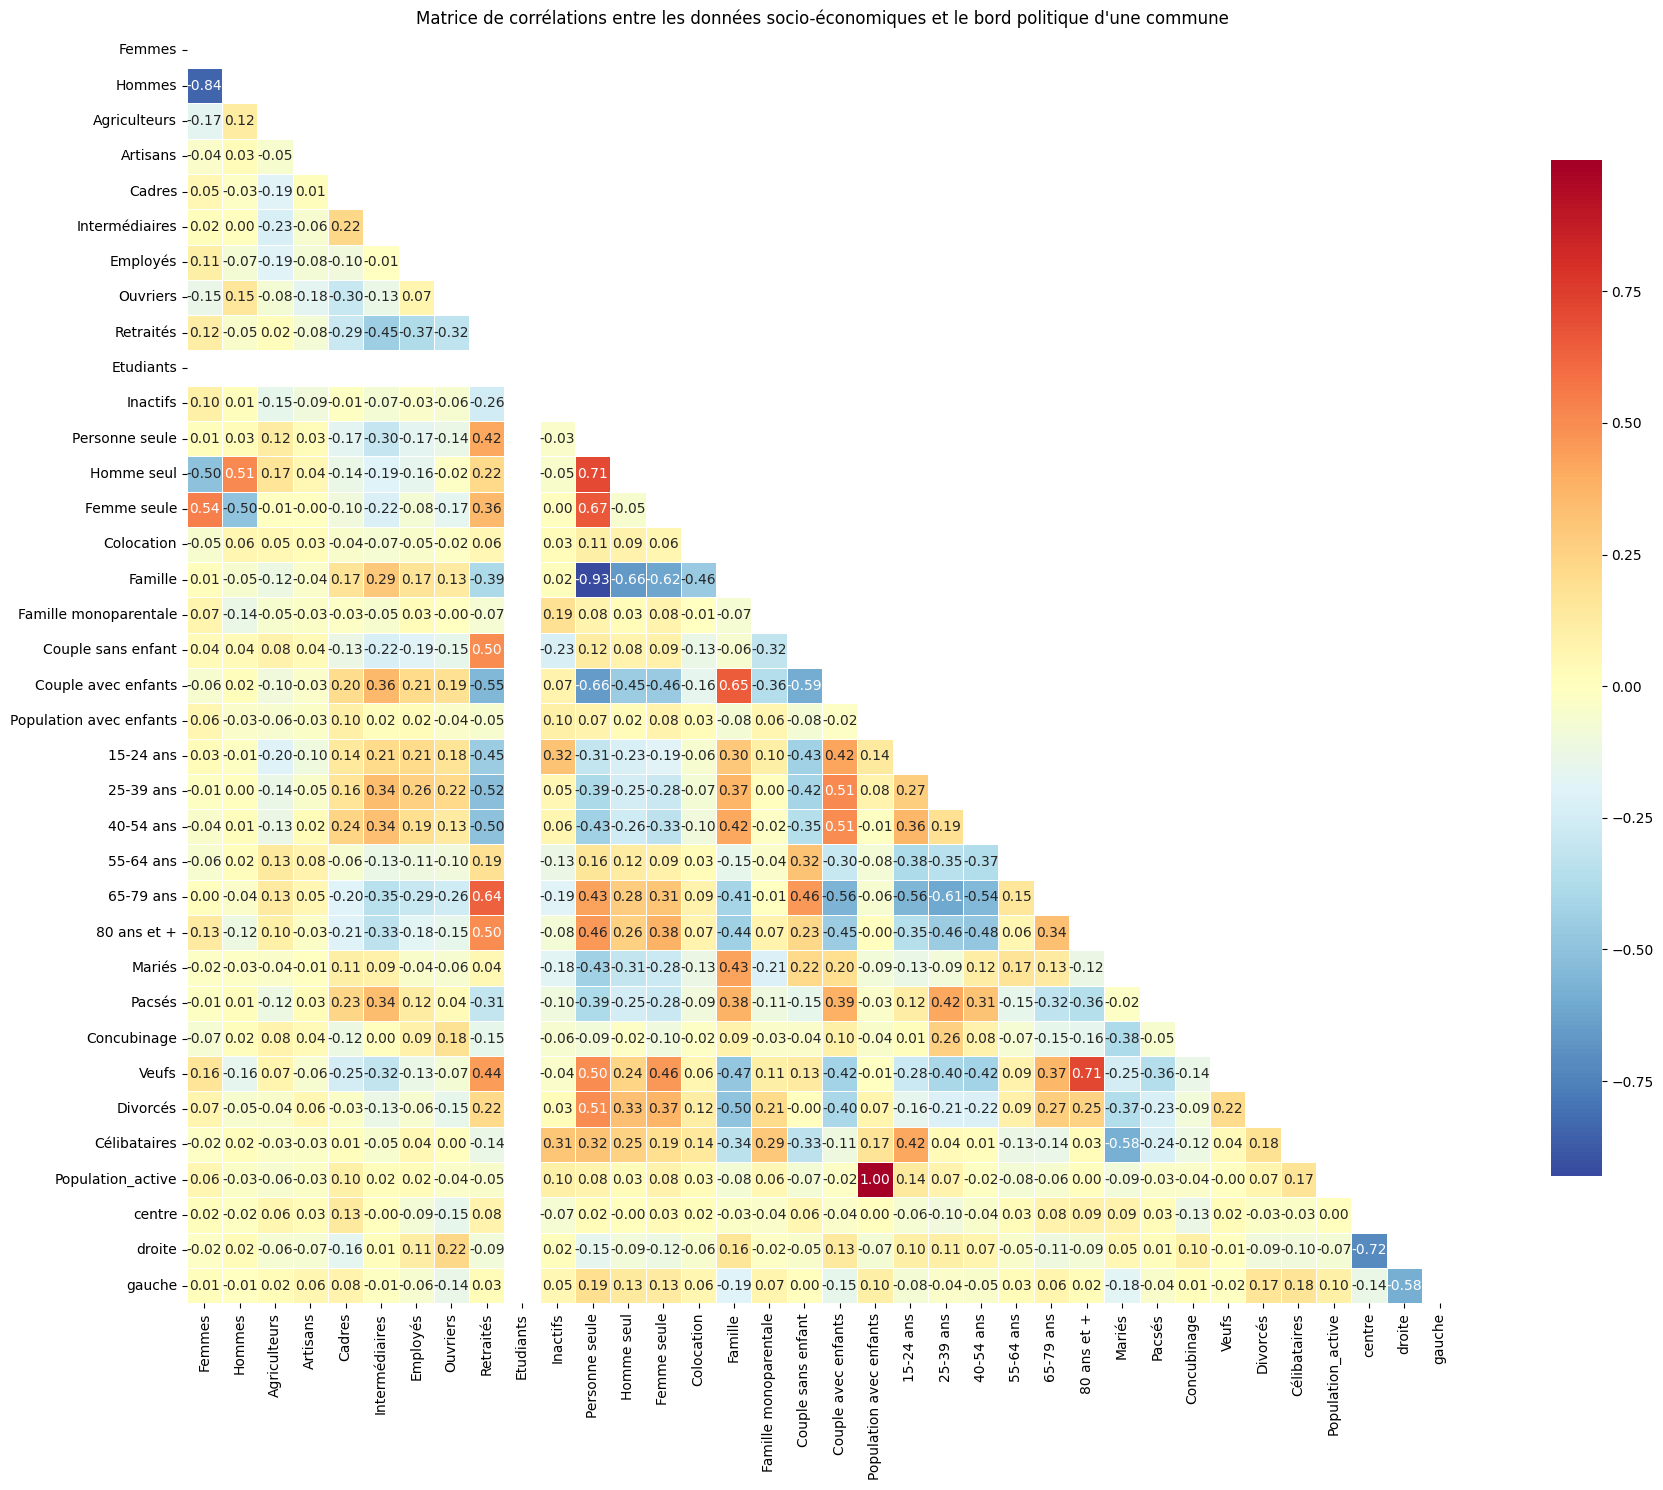

In [4]:
target_dummies = pd.get_dummies(df['Résultat'])
df_corr = pd.concat([df.select_dtypes(include='number'), target_dummies], axis=1)
corr_matrix = df_corr.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20, 15))

sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, mask=mask, cbar_kws={"shrink": .8}, 
            fmt='.2f', linewidths=0.5)

plt.title('Matrice de corrélations entre les données socio-économiques et le bord politique d\'une commune')
plt.tight_layout()
plt.show()

- Pas de corrélation vraiment signifiante
- Le taux de cadres et d'ouvriers pourrait avoir une certaine influence sur le vote
- Idem pour le taux de familles, couples avec enfant et personnes seules
- Idem pour les personnes mariées VS divorcés et célibataires
- Le genre et la tranche d'âge semblent n'avoir aucun impact sur le vote politique d'une commune

# Analyse bivariée

## Population

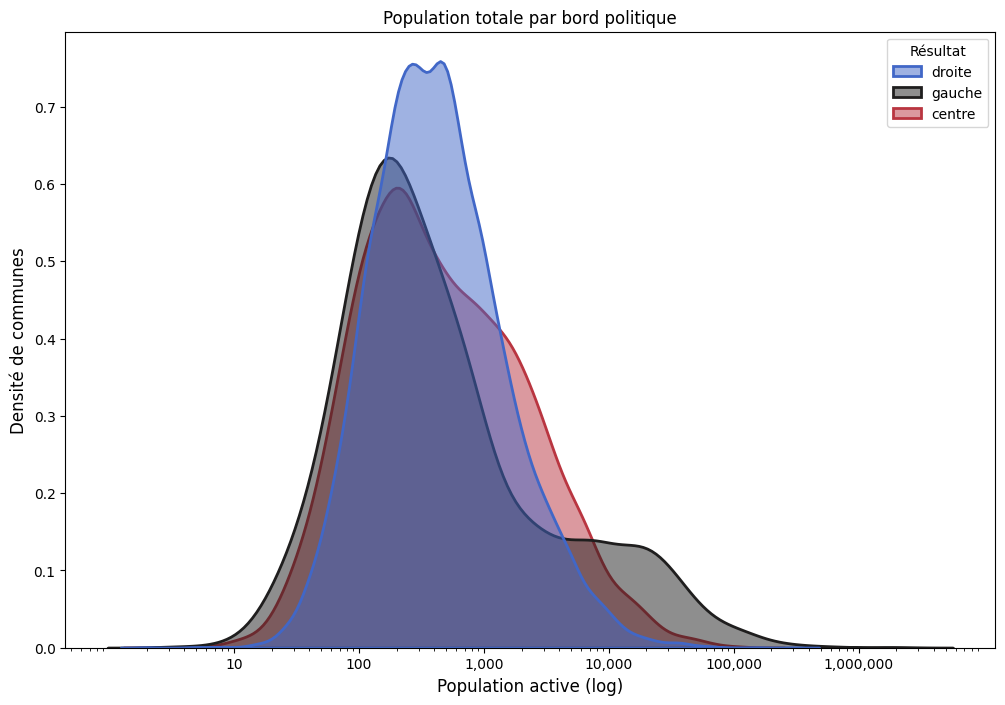

In [5]:
sns.kdeplot(data=df, x='Population_active', hue='Résultat', 
            log_scale=True, fill=True, common_norm=False, 
            palette='icefire', alpha=0.5, linewidth=2)

plt.xlabel('Population active (log)', fontsize=12)
plt.ylabel('Densité de communes', fontsize=12)

plt.title('Population totale par bord politique')

ticks = [10, 100, 1000, 10000, 100000, 1000000]
plt.xticks(ticks, [f'{t:,}' for t in ticks])

plt.show()

- La droite est beaucoup plus présente dans les communes petites-moyennes (entre 200 et 1000 habitants)
- La gauche est plus présente dans les très grandes villes (à partir de 10000 habitants)
- Le centre est entre les deux, pas de caractéristique distinctive

## Genre

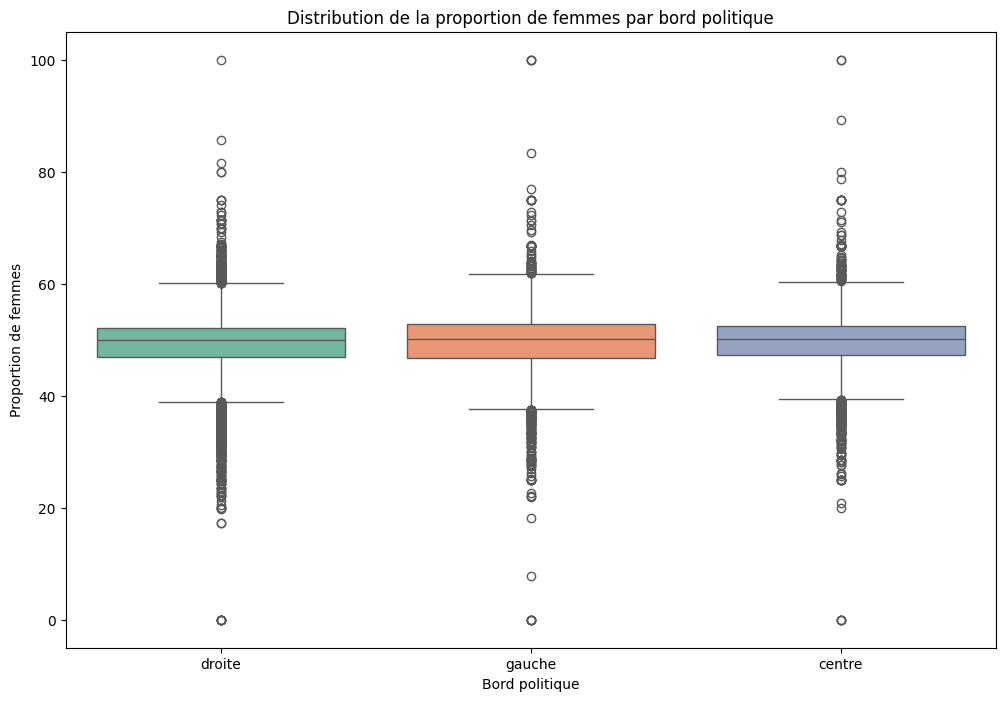

In [6]:
sns.boxplot(data=df, x=df['Résultat'], y=df['Femmes'], hue=df['Résultat'], palette='Set2', showfliers=True)

plt.title('Distribution de la proportion de femmes par bord politique')
plt.xlabel('Bord politique')
plt.ylabel('Proportion de femmes')

plt.show()

Le genre majoritaire dans une commune n'a aucun impact sur le bord politique

## Catégories socio-professionnelles

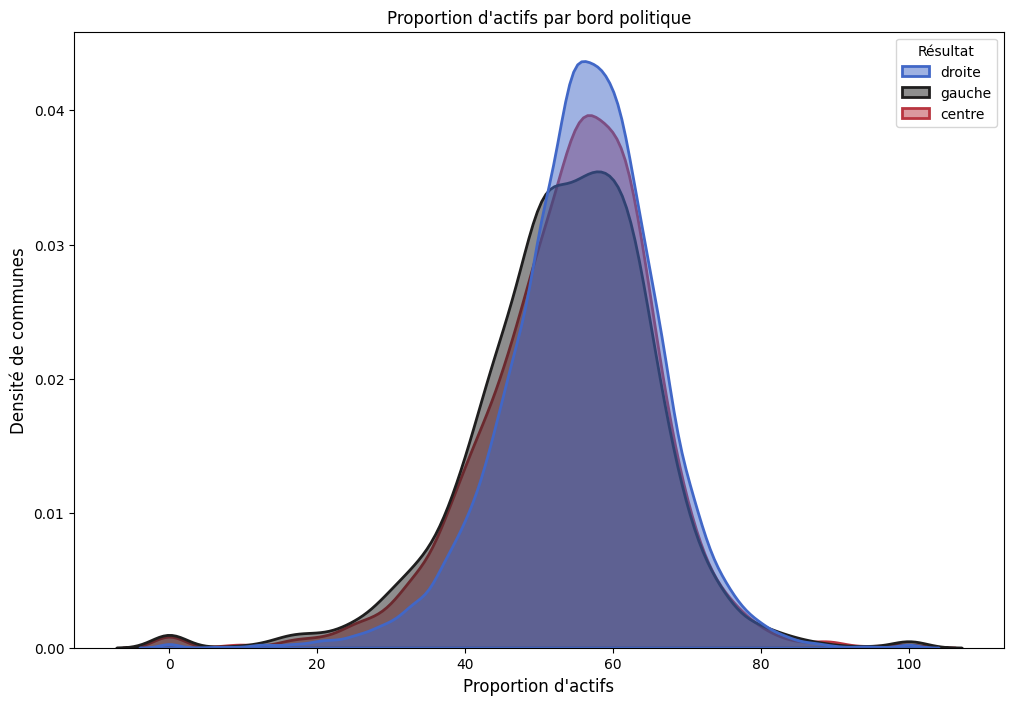

In [ ]:
df_csp = df[['Résultat', 'Population_active', 'Agriculteurs', 'Artisans', 'Cadres', 'Intermédiaires', 'Employés', 'Ouvriers', 'Etudiants', 'Retraités', 'Inactifs']]
df_csp['Total_actifs'] = df_csp['Agriculteurs'] + df_csp['Artisans'] + df_csp['Cadres'] + df_csp['Intermédiaires'] + df_csp['Employés'] + df_csp['Ouvriers']


sns.kdeplot(data=df_csp, x='Total_actifs', hue='Résultat', 
            log_scale=False, fill=True, common_norm=False, 
            palette='icefire', alpha=0.5, linewidth=2)

plt.xlabel('Proportion d\'actifs', fontsize=12)
plt.ylabel('Densité de communes', fontsize=12)

plt.title('Proportion d\'actifs par bord politique')

plt.show()

- Entre 50 et 70 % d'actifs dans une commune, la droite est plus présente
- Entre 25 et 50 % d'actifs dans une commune, la gauche est plus présente
- Le centre est entre les deux
- On pourrait créer une variable booléenne majorité_actifs (True si la proportion > 50 %, sinon False)

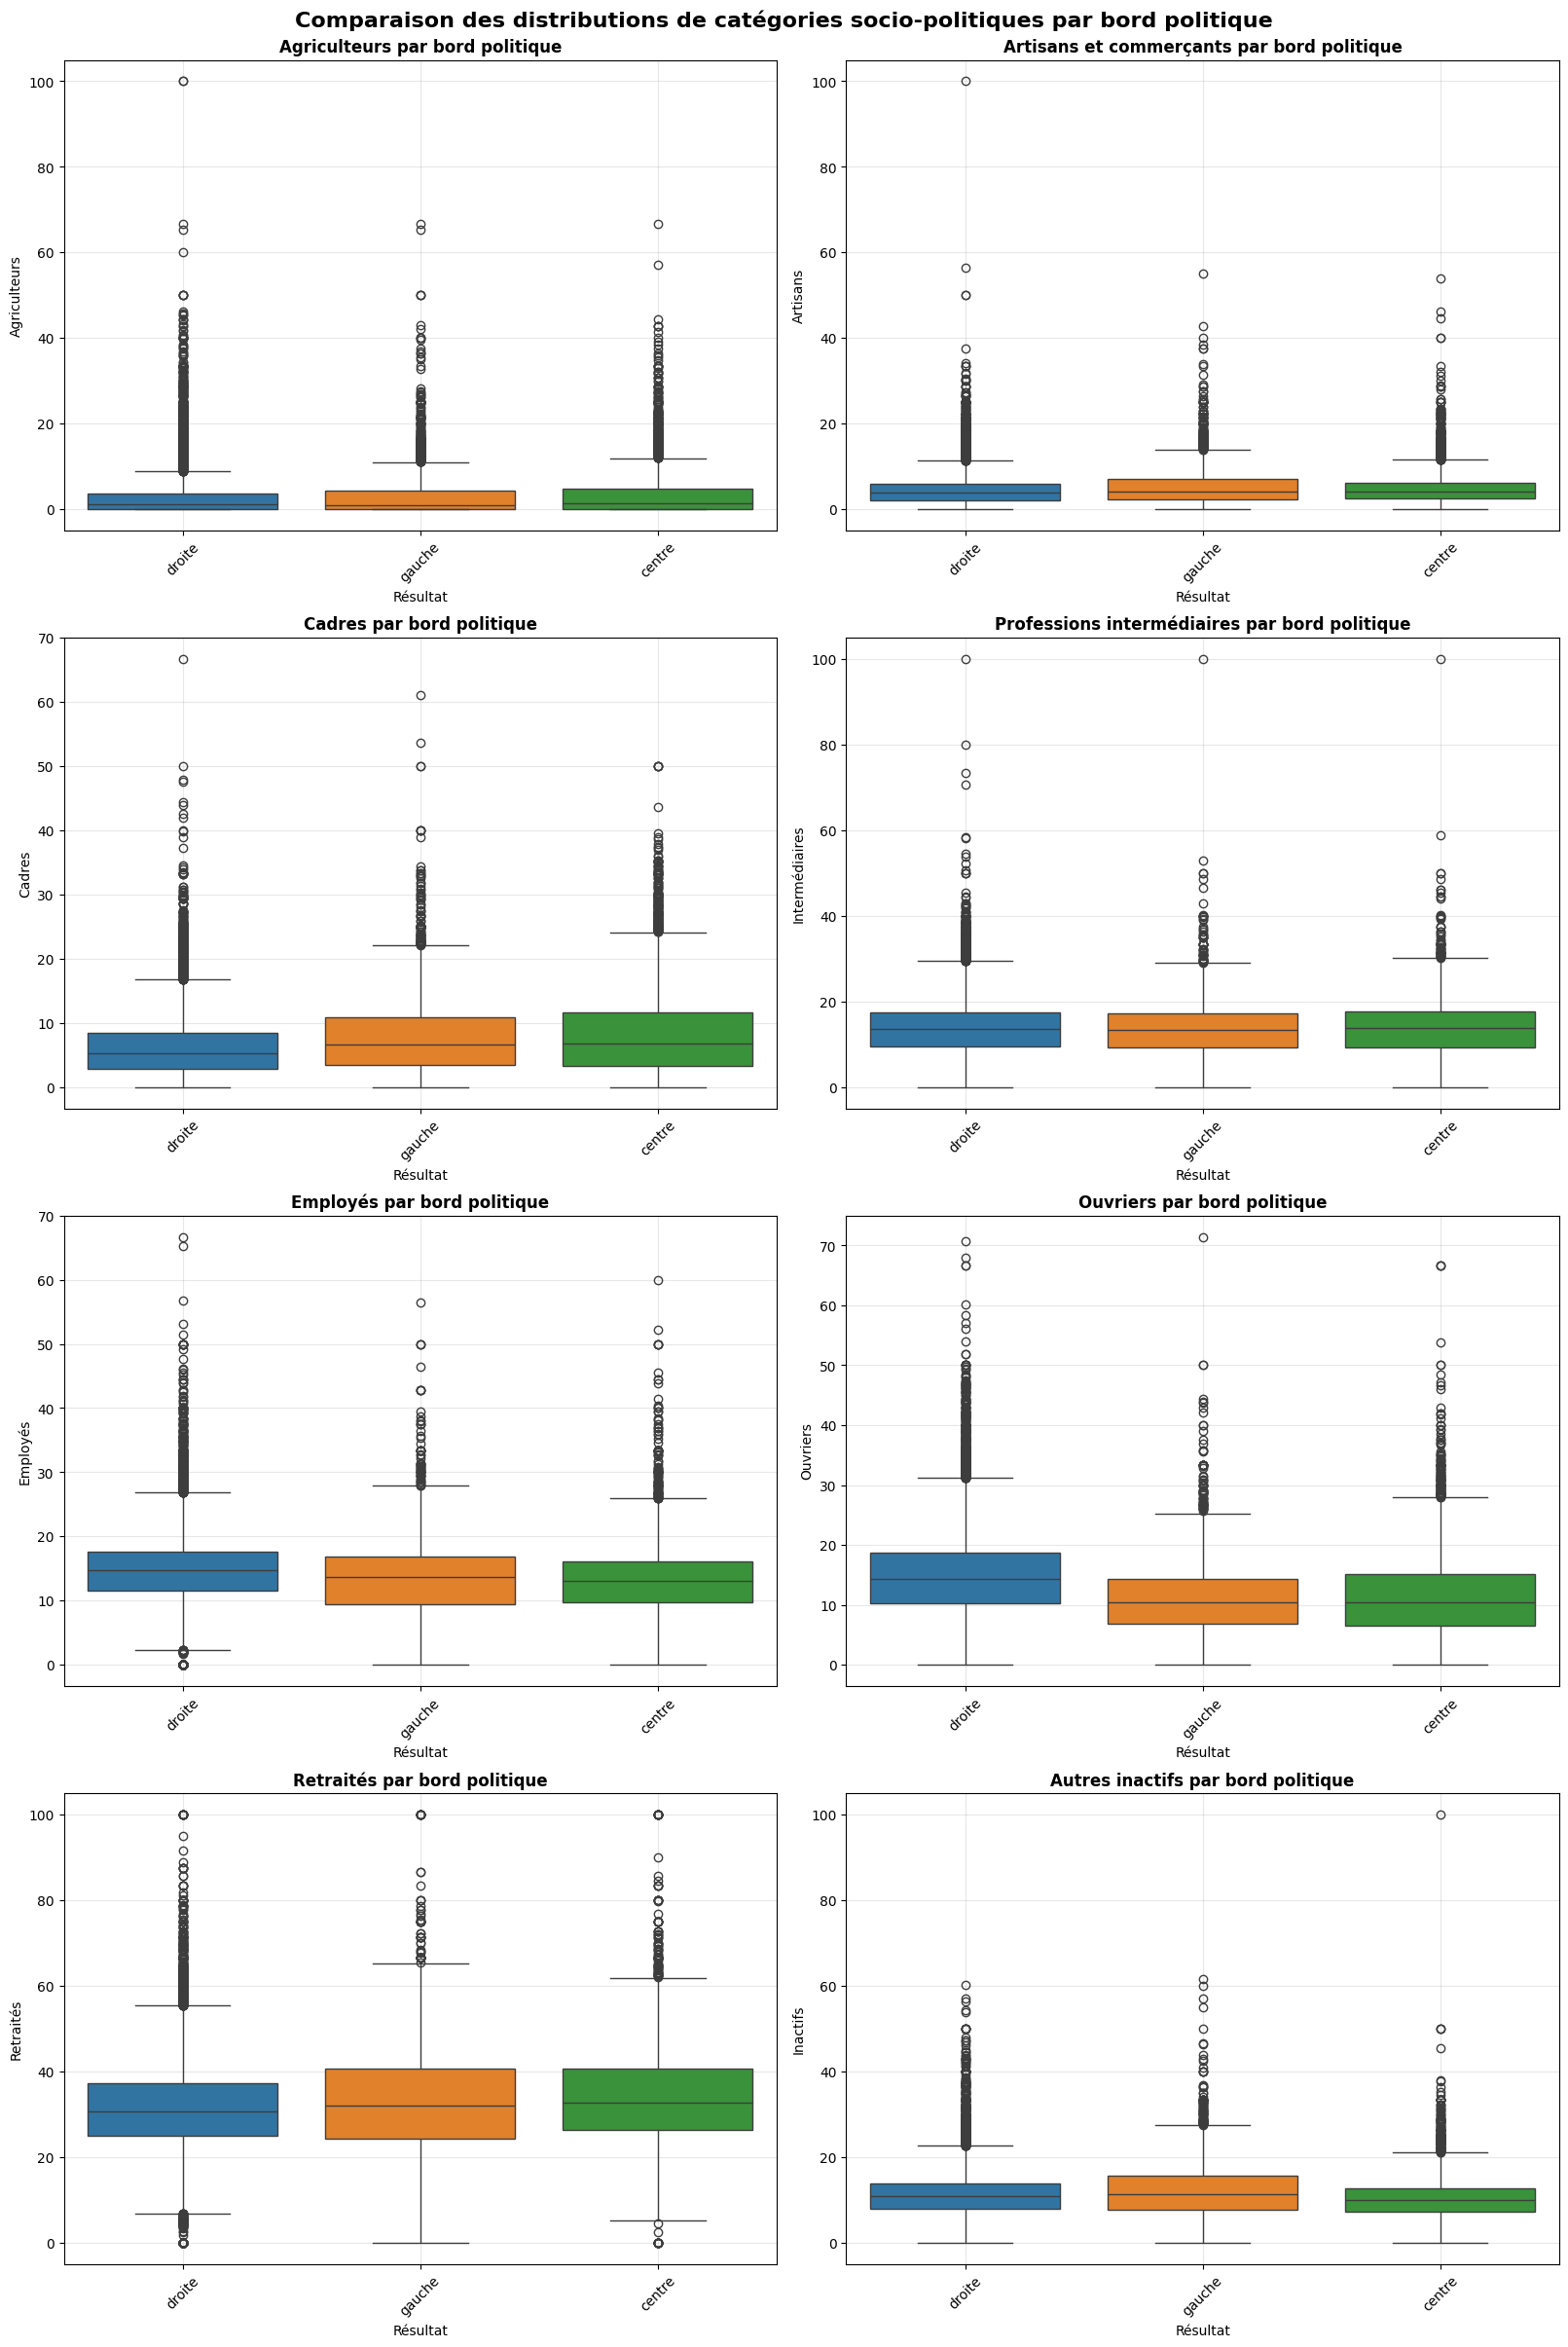

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24), layout="constrained")
fig.suptitle('Comparaison des distributions de catégories socio-politiques par bord politique', fontsize=16, fontweight='bold')

comparisons = [
    ('Agriculteurs', 'Agriculteurs par bord politique'),
    ('Artisans', 'Artisans et commerçants par bord politique'),
    ('Cadres', 'Cadres par bord politique'),
    ('Intermédiaires', 'Professions intermédiaires par bord politique'),
    ('Employés', 'Employés par bord politique'),
    ('Ouvriers', 'Ouvriers par bord politique'),
    ('Retraités', 'Retraités par bord politique'),
    ('Inactifs', 'Autres inactifs par bord politique')
]

for i, (num_var, title) in enumerate(comparisons):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    sns.boxplot(data=df_csp, x='Résultat', y=num_var, ax=ax, 
                hue='Résultat', showfliers=True)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Résultat'.title())
    ax.set_ylabel(num_var.title())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# plt.tight_layout()
plt.show()

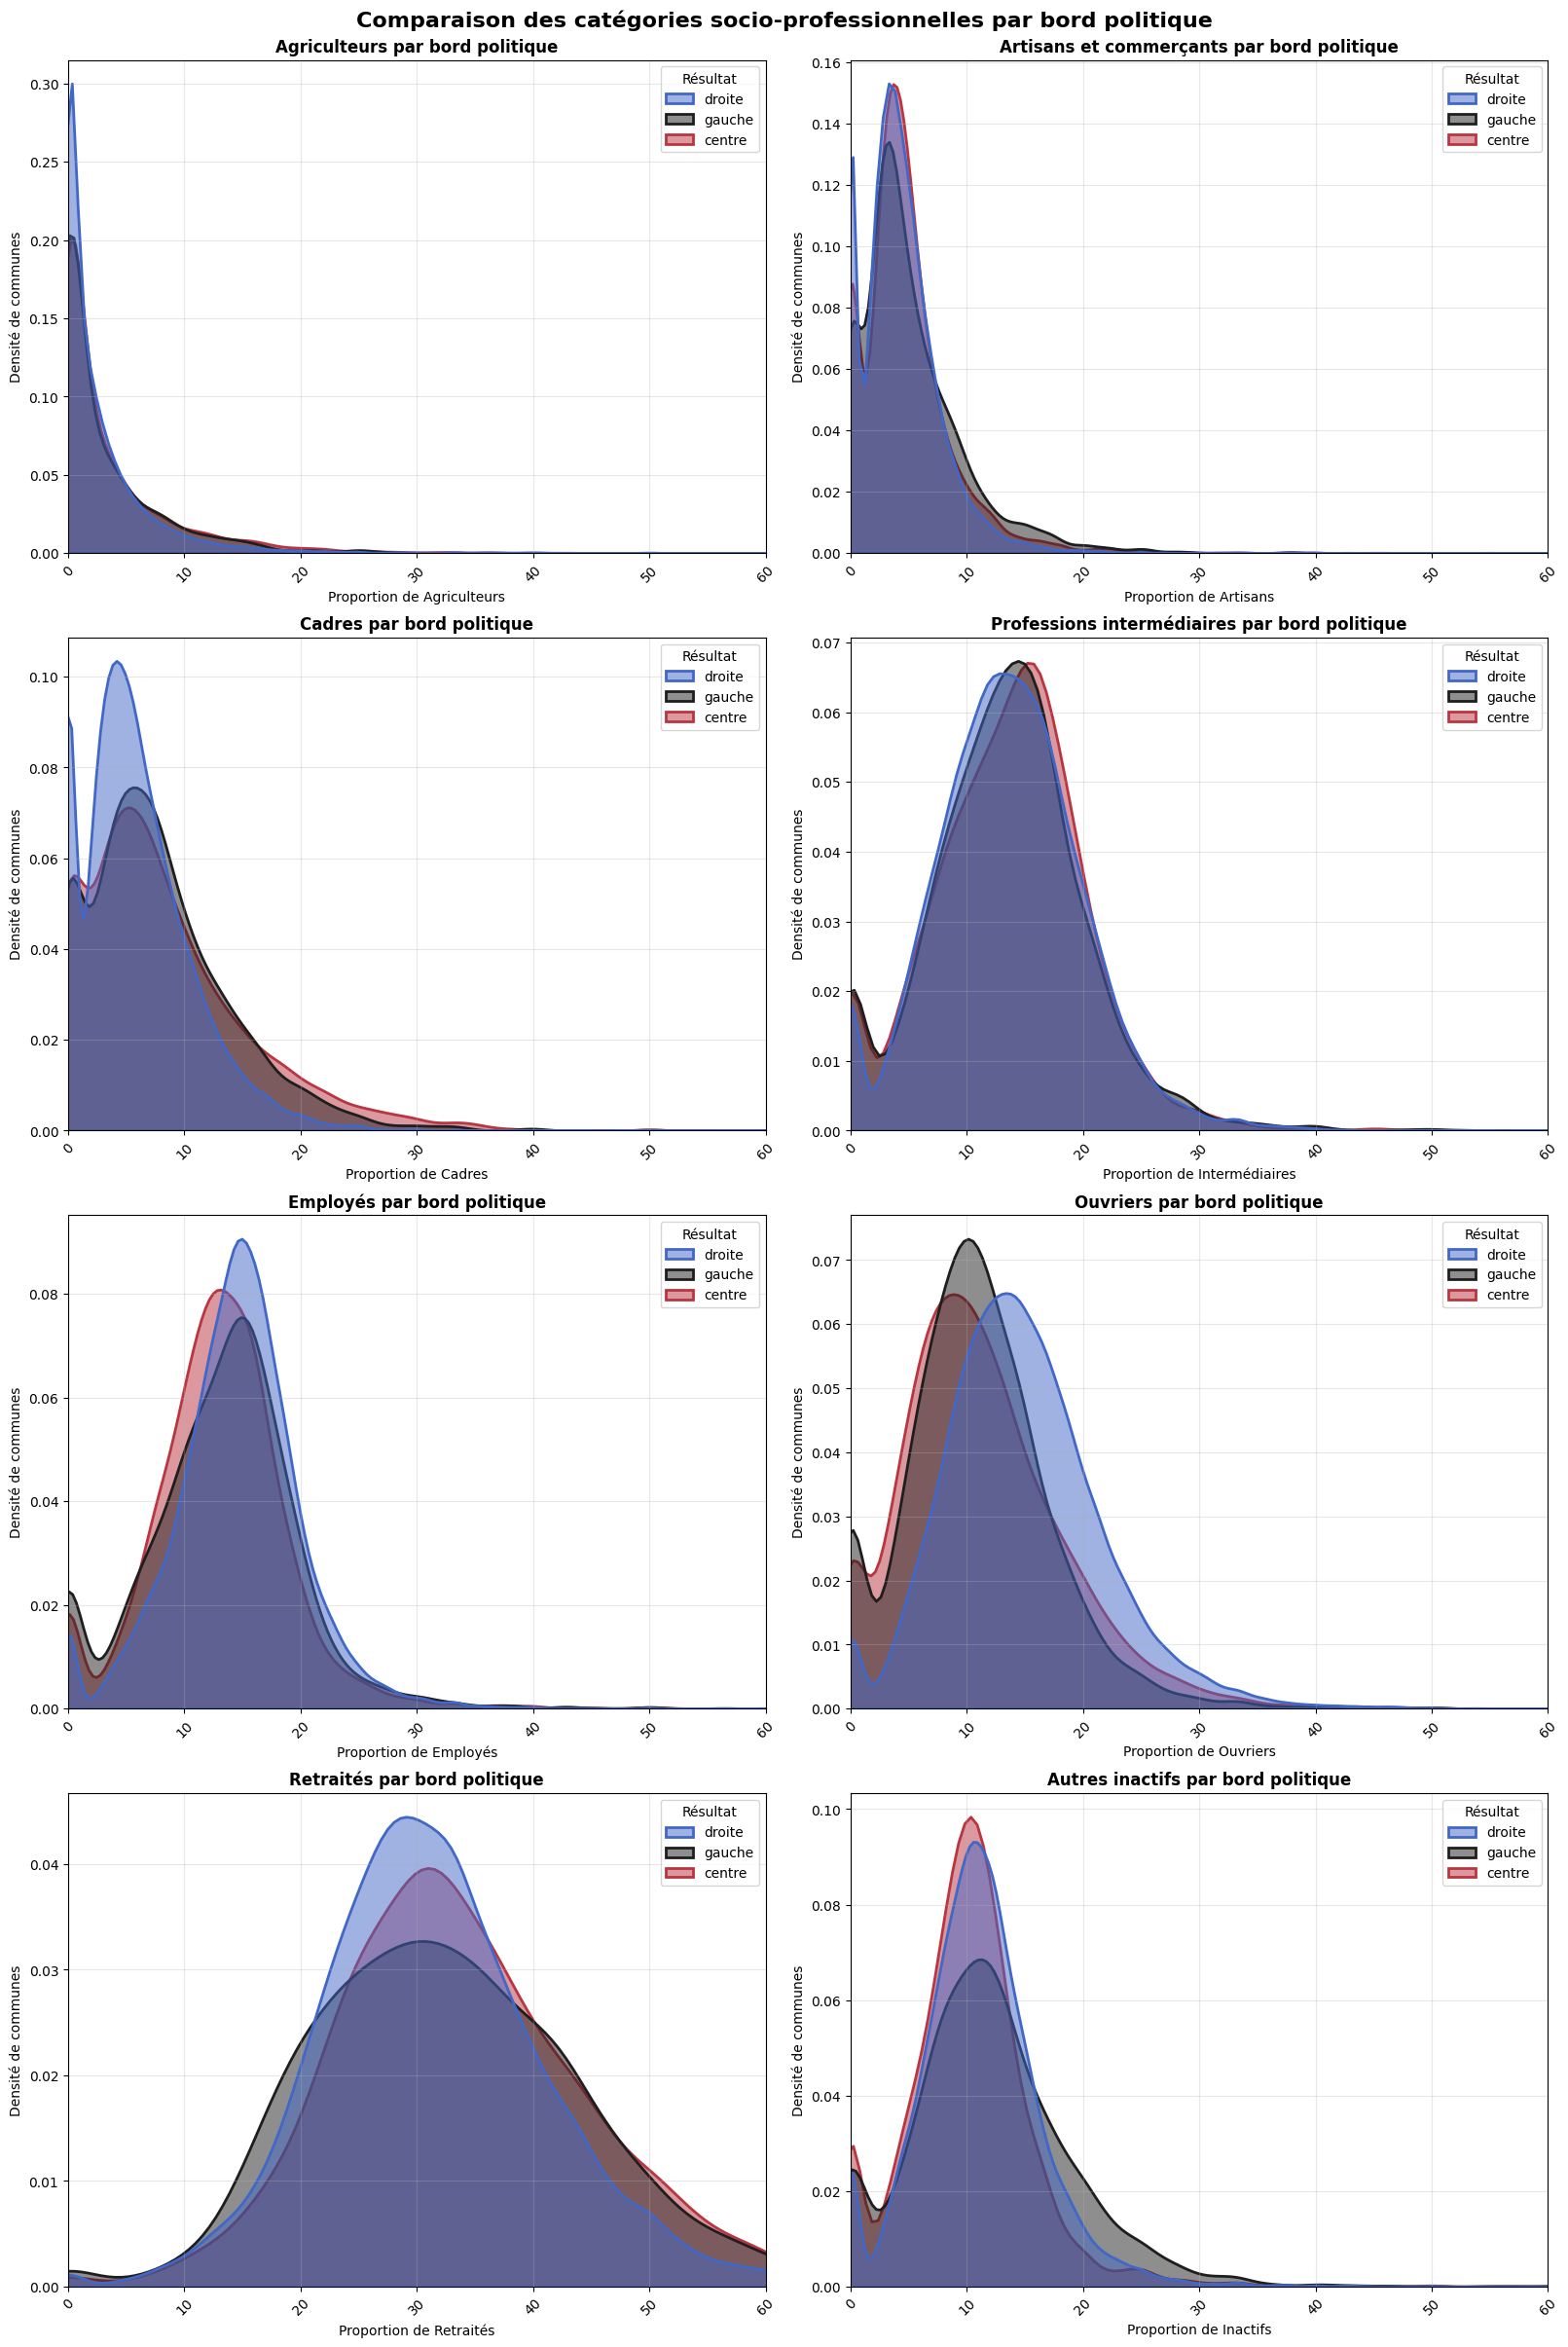

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24), layout="constrained")
fig.suptitle('Comparaison des catégories socio-professionnelles par bord politique', fontsize=16, fontweight='bold')

comparisons = [
    ('Agriculteurs', 'Agriculteurs par bord politique'),
    ('Artisans', 'Artisans et commerçants par bord politique'),
    ('Cadres', 'Cadres par bord politique'),
    ('Intermédiaires', 'Professions intermédiaires par bord politique'),
    ('Employés', 'Employés par bord politique'),
    ('Ouvriers', 'Ouvriers par bord politique'),
    ('Retraités', 'Retraités par bord politique'),
    ('Inactifs', 'Autres inactifs par bord politique')
]


for i, (var, title) in enumerate(comparisons):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    sns.kdeplot(data=df_csp, x=var, hue='Résultat', 
            log_scale=False, fill=True, common_norm=False, 
            palette='icefire', alpha=0.5, linewidth=2, ax=ax)
    
    ax.set_xlim(0, 60)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'Proportion de {var.title()}')
    ax.set_ylabel('Densité de communes')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.show()

- Moins de 2 % d'agriculteurs = droite
- A partir de 10 % de cadres, = chute de la droite
- A partir de 38 % de retraités = chute de la droite
- A partir de 12 % d'employés = droite
- A partir de 12 % d'ouvriers = droite
- A partir de 17 % d'autres inactifs = gauche

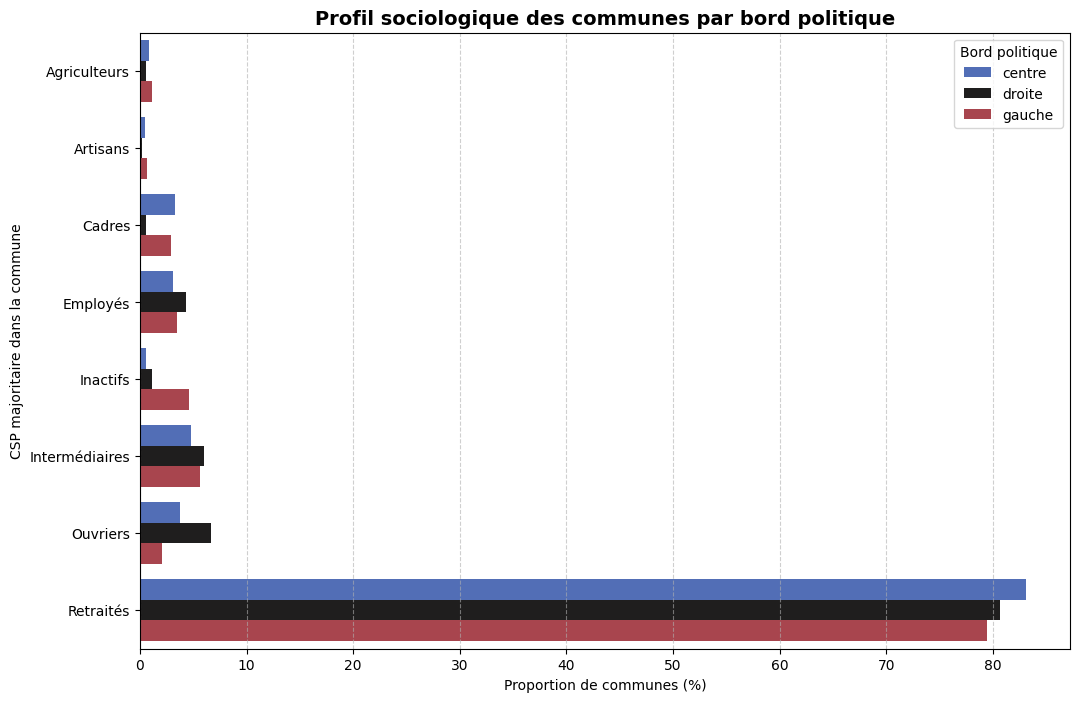

In [24]:
cols_groups = ['Agriculteurs', 'Artisans', 'Cadres', 'Intermédiaires', 'Employés', 'Ouvriers', 'Etudiants', 'Retraités', 'Inactifs']
mask = df_csp[cols_groups].notna().any(axis=1)
df_csp.loc[mask, 'Majorité'] = df_csp.loc[mask, cols_groups].idxmax(axis=1)

# 1. Préparation des données : on calcule le % de chaque CSP au sein de chaque bord
df_counts = df_csp.groupby(['Résultat', 'Majorité']).size().reset_index(name='count')
df_counts['densité'] = df_counts.groupby('Résultat')['count'].transform(lambda x: x / x.sum() * 100)


plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_counts, 
    y='Majorité',      # Les CSP sur l'axe Y
    x='densité',       # La proportion sur l'axe X
    hue='Résultat',    # Les 3 barres par catégorie
    palette='icefire'
)

plt.title('Profil sociologique des communes par bord politique', fontweight='bold', fontsize=14)
plt.xlabel('Proportion de communes (%)')
plt.ylabel('CSP majoritaire dans la commune')
plt.legend(title='Bord politique')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

- Autres inactifs majoritaires = gauche
- Cadres, artisans ou agriculteurs majoritaires = pas droite
- Ouvriers majoritaires = pas gauche, surtout droite
- Employés, intermédiaires ou retraités majoritaires = légère hiérarchie

## Tranches d'âge

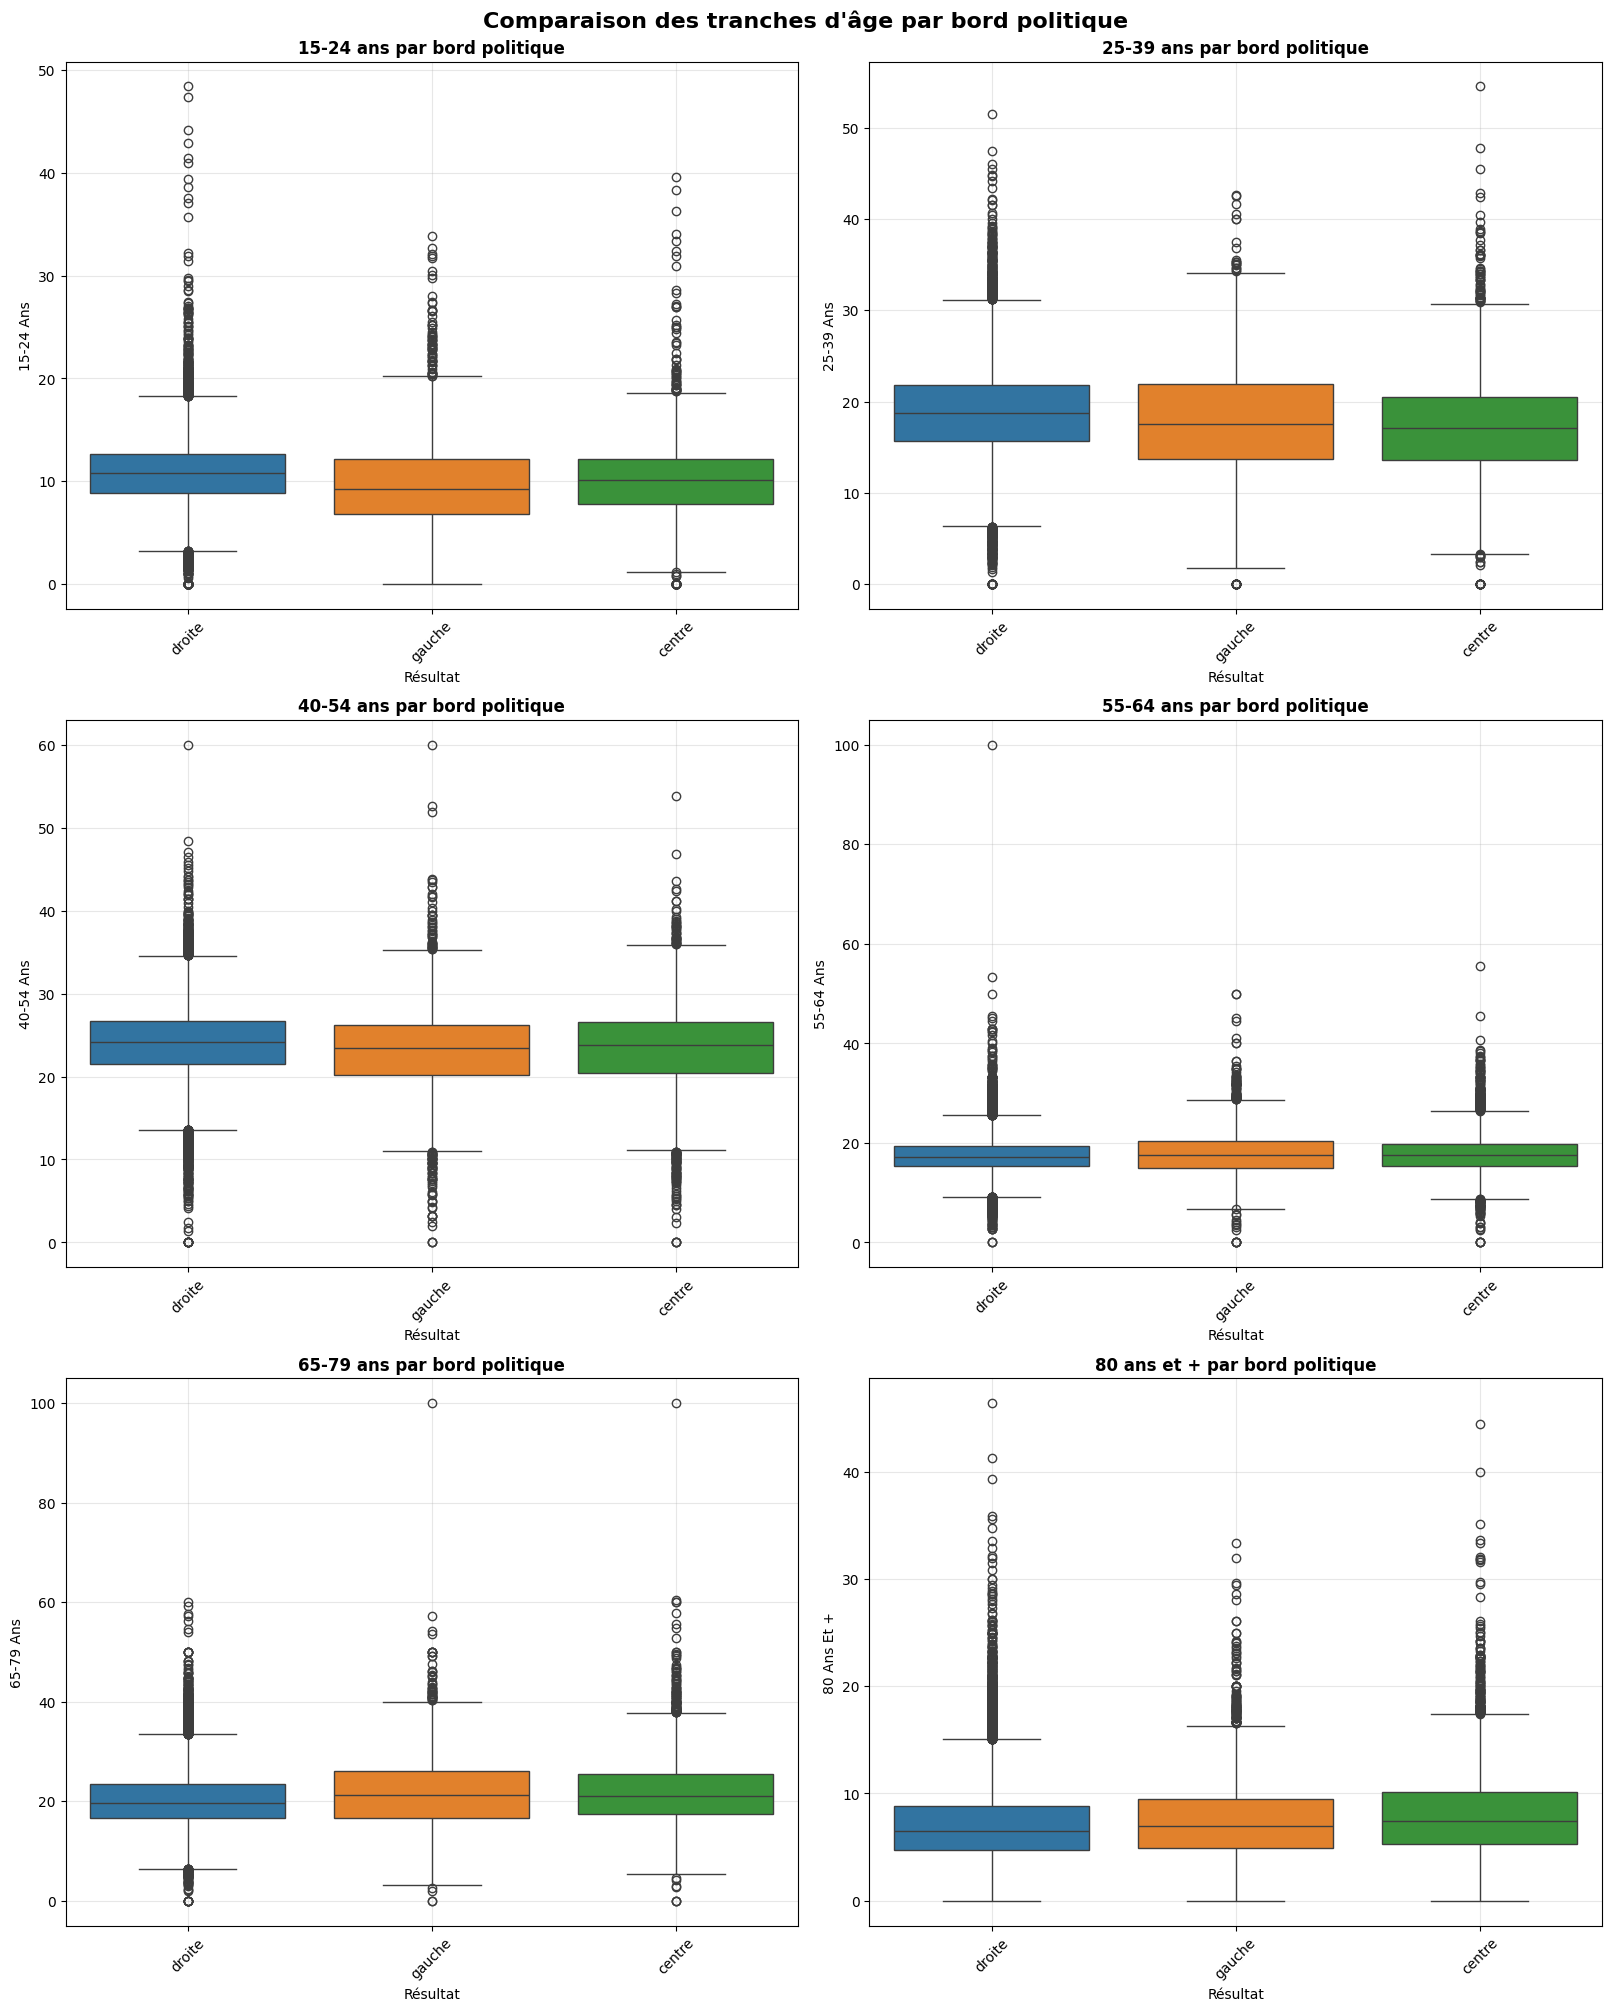

In [15]:
df_age = df[['Résultat', '15-24 ans', '25-39 ans', '40-54 ans', '55-64 ans', '65-79 ans', '80 ans et +']]

fig, axes = plt.subplots(3, 2, figsize=(16, 20), layout="constrained")
fig.suptitle('Comparaison des tranches d\'âge par bord politique', fontsize=16, fontweight='bold')

comparisons = [
    ('15-24 ans', '15-24 ans par bord politique'),
    ('25-39 ans', '25-39 ans par bord politique'),
    ('40-54 ans', '40-54 ans par bord politique'),
    ('55-64 ans', '55-64 ans par bord politique'),
    ('65-79 ans', '65-79 ans par bord politique'),
    ('80 ans et +', '80 ans et + par bord politique')
]

for i, (var, title) in enumerate(comparisons):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    sns.boxplot(data=df_age, x='Résultat', y=var, ax=ax, 
                hue='Résultat', showfliers=True)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Résultat'.title())
    ax.set_ylabel(var.title())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.show()

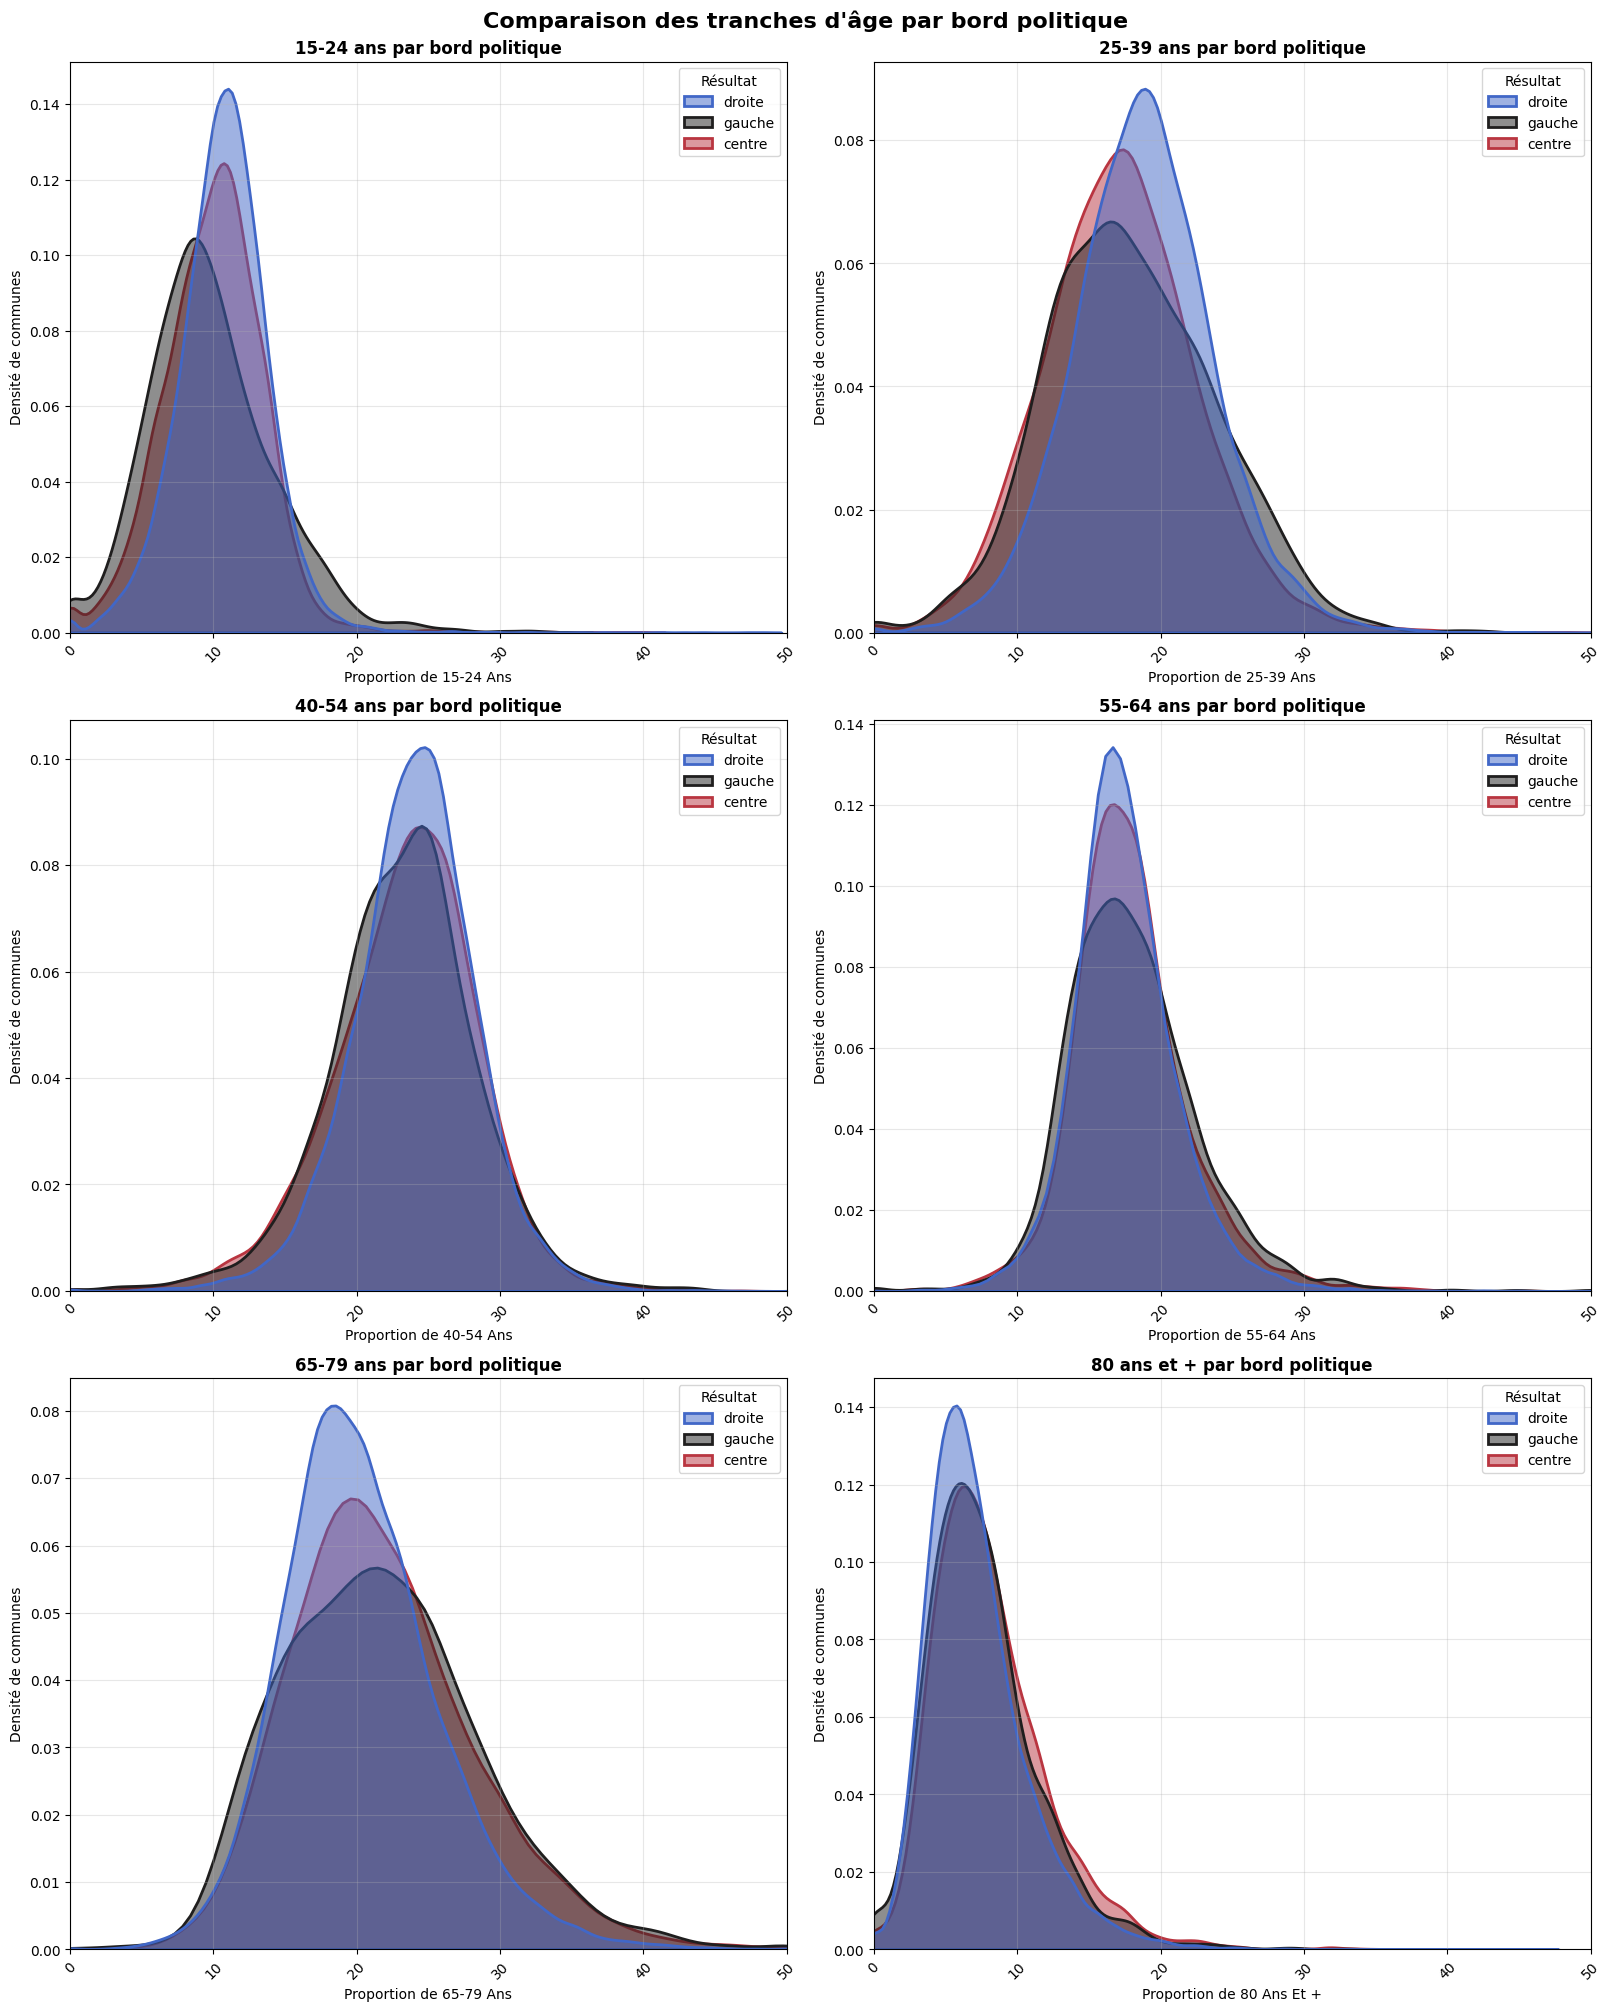

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20), layout="constrained")
fig.suptitle('Comparaison des tranches d\'âge par bord politique', fontsize=16, fontweight='bold')

comparisons = [
    ('15-24 ans', '15-24 ans par bord politique'),
    ('25-39 ans', '25-39 ans par bord politique'),
    ('40-54 ans', '40-54 ans par bord politique'),
    ('55-64 ans', '55-64 ans par bord politique'),
    ('65-79 ans', '65-79 ans par bord politique'),
    ('80 ans et +', '80 ans et + par bord politique')
]

for i, (var, title) in enumerate(comparisons):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    sns.kdeplot(data=df_age, x=var, hue='Résultat', 
        log_scale=False, fill=True, common_norm=False, 
        palette='icefire', alpha=0.5, linewidth=2, ax=ax)
    
    ax.set_xlim(0, 50)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'Proportion de {var.title()}')
    ax.set_ylabel('Densité de communes')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.show()


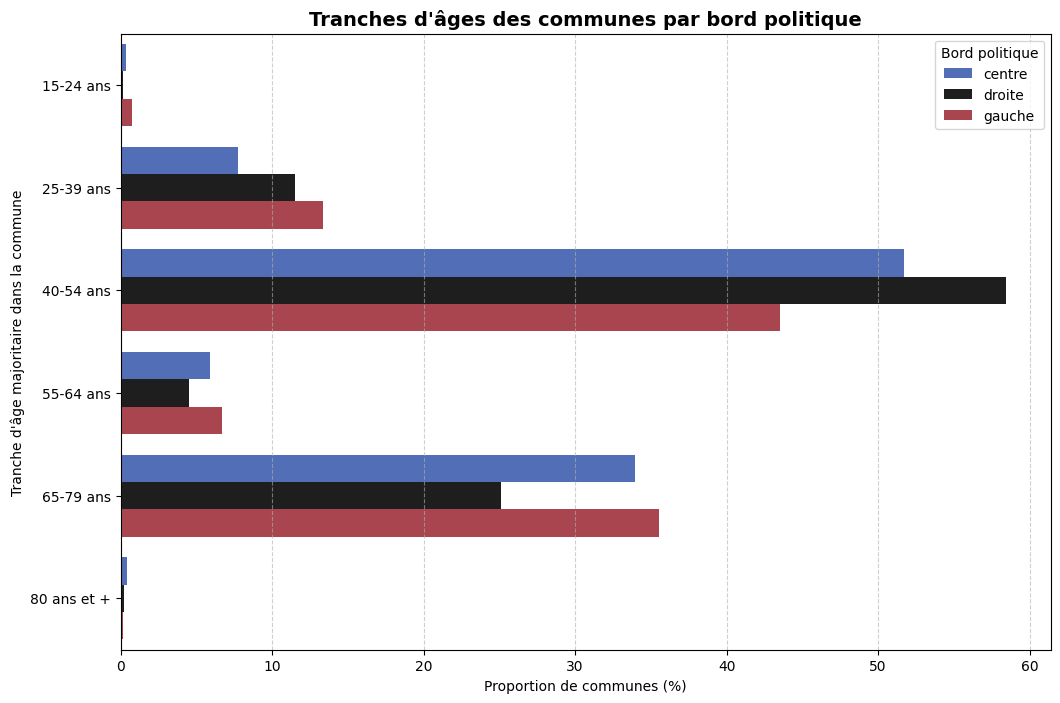

In [27]:
cols_ages = ['15-24 ans', '25-39 ans', '40-54 ans', '55-64 ans', '65-79 ans', '80 ans et +']
mask = df_age[cols_ages].notna().any(axis=1)
df_age.loc[mask, 'Majorité'] = df_age.loc[mask, cols_ages].idxmax(axis=1)

# 1. Préparation des données : on calcule le % de chaque CSP au sein de chaque bord
df_counts_ages = df_age.groupby(['Résultat', 'Majorité']).size().reset_index(name='count')
df_counts_ages['Densité'] = df_counts_ages.groupby('Résultat')['count'].transform(lambda x: x / x.sum() * 100)


plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_counts_ages, 
    y='Majorité',      # Les CSP sur l'axe Y
    x='Densité',       # La proportion sur l'axe X
    hue='Résultat',    # Les 3 barres par catégorie
    palette='icefire'
)

plt.title('Tranches d\'âges des communes par bord politique', fontweight='bold', fontsize=14)
plt.xlabel('Proportion de communes (%)')
plt.ylabel('Tranche d\'âge majoritaire dans la commune')
plt.legend(title='Bord politique')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

## Composition du ménage

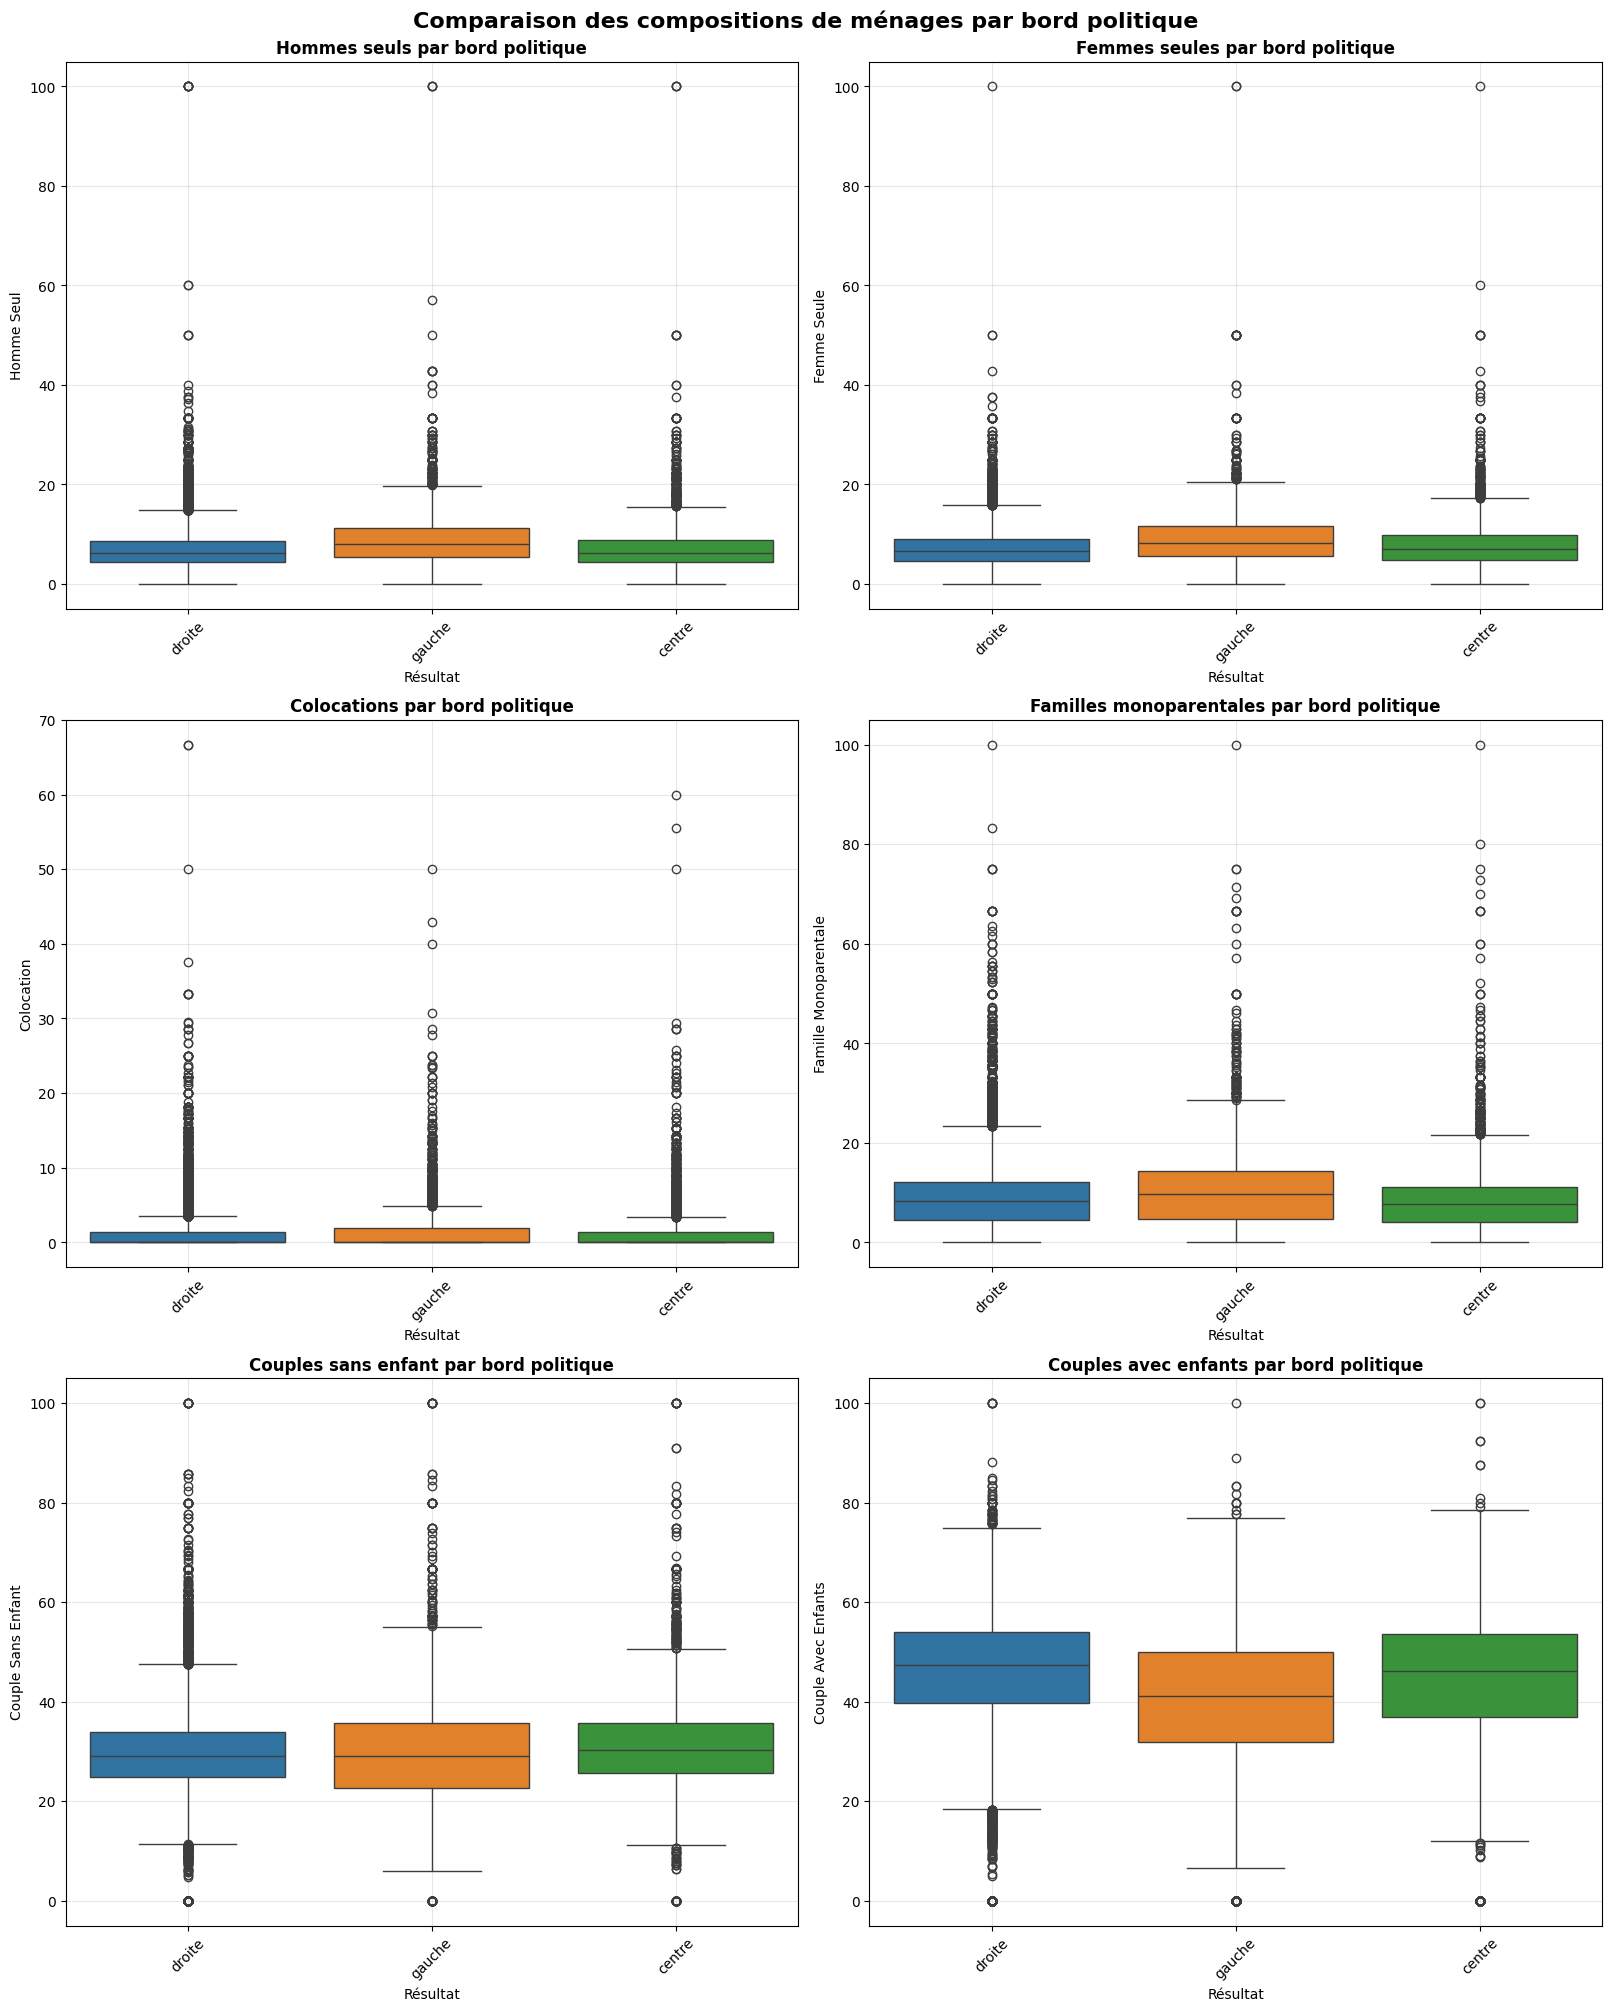

In [31]:
df_household = df[['Résultat', 'Personne seule', 'Homme seul', 'Femme seule', 'Colocation', 'Famille', 'Famille monoparentale', 'Couple sans enfant', 'Couple avec enfants']]

fig, axes = plt.subplots(3, 2, figsize=(16, 20), layout="constrained")
fig.suptitle('Comparaison des compositions de ménages par bord politique', fontsize=16, fontweight='bold')

comparisons = [
    ('Homme seul', 'Hommes seuls par bord politique'),
    ('Femme seule', 'Femmes seules par bord politique'),
    ('Colocation', 'Colocations par bord politique'),
    ('Famille monoparentale', 'Familles monoparentales par bord politique'),
    ('Couple sans enfant', 'Couples sans enfant par bord politique'),
    ('Couple avec enfants', 'Couples avec enfants par bord politique')
]

for i, (var, title) in enumerate(comparisons):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    sns.boxplot(data=df_household, x='Résultat', y=var, ax=ax, 
                hue='Résultat', showfliers=True)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Résultat'.title())
    ax.set_ylabel(var.title())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.show()

- La proportion de couples avec enfants semble influencer légèrement le vote (la gauche est moins représentée)

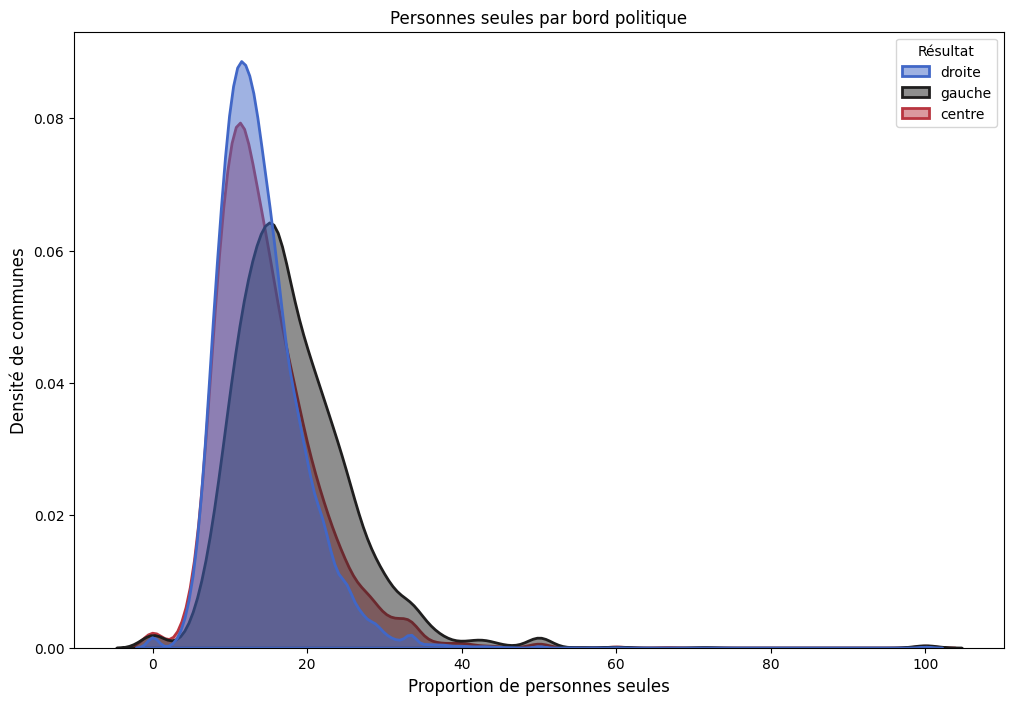

In [34]:
sns.kdeplot(data=df_household, x='Personne seule', hue='Résultat', 
            log_scale=False, fill=True, common_norm=False, 
            palette='icefire', alpha=0.5, linewidth=2)

plt.xlabel('Proportion de personnes seules', fontsize=12)
plt.ylabel('Densité de communes', fontsize=12)

plt.title('Personnes seules par bord politique')

plt.show()


Plus la proportion de personnes seules est importante, plus les communes s'éloignent de la droite

## Statut marital

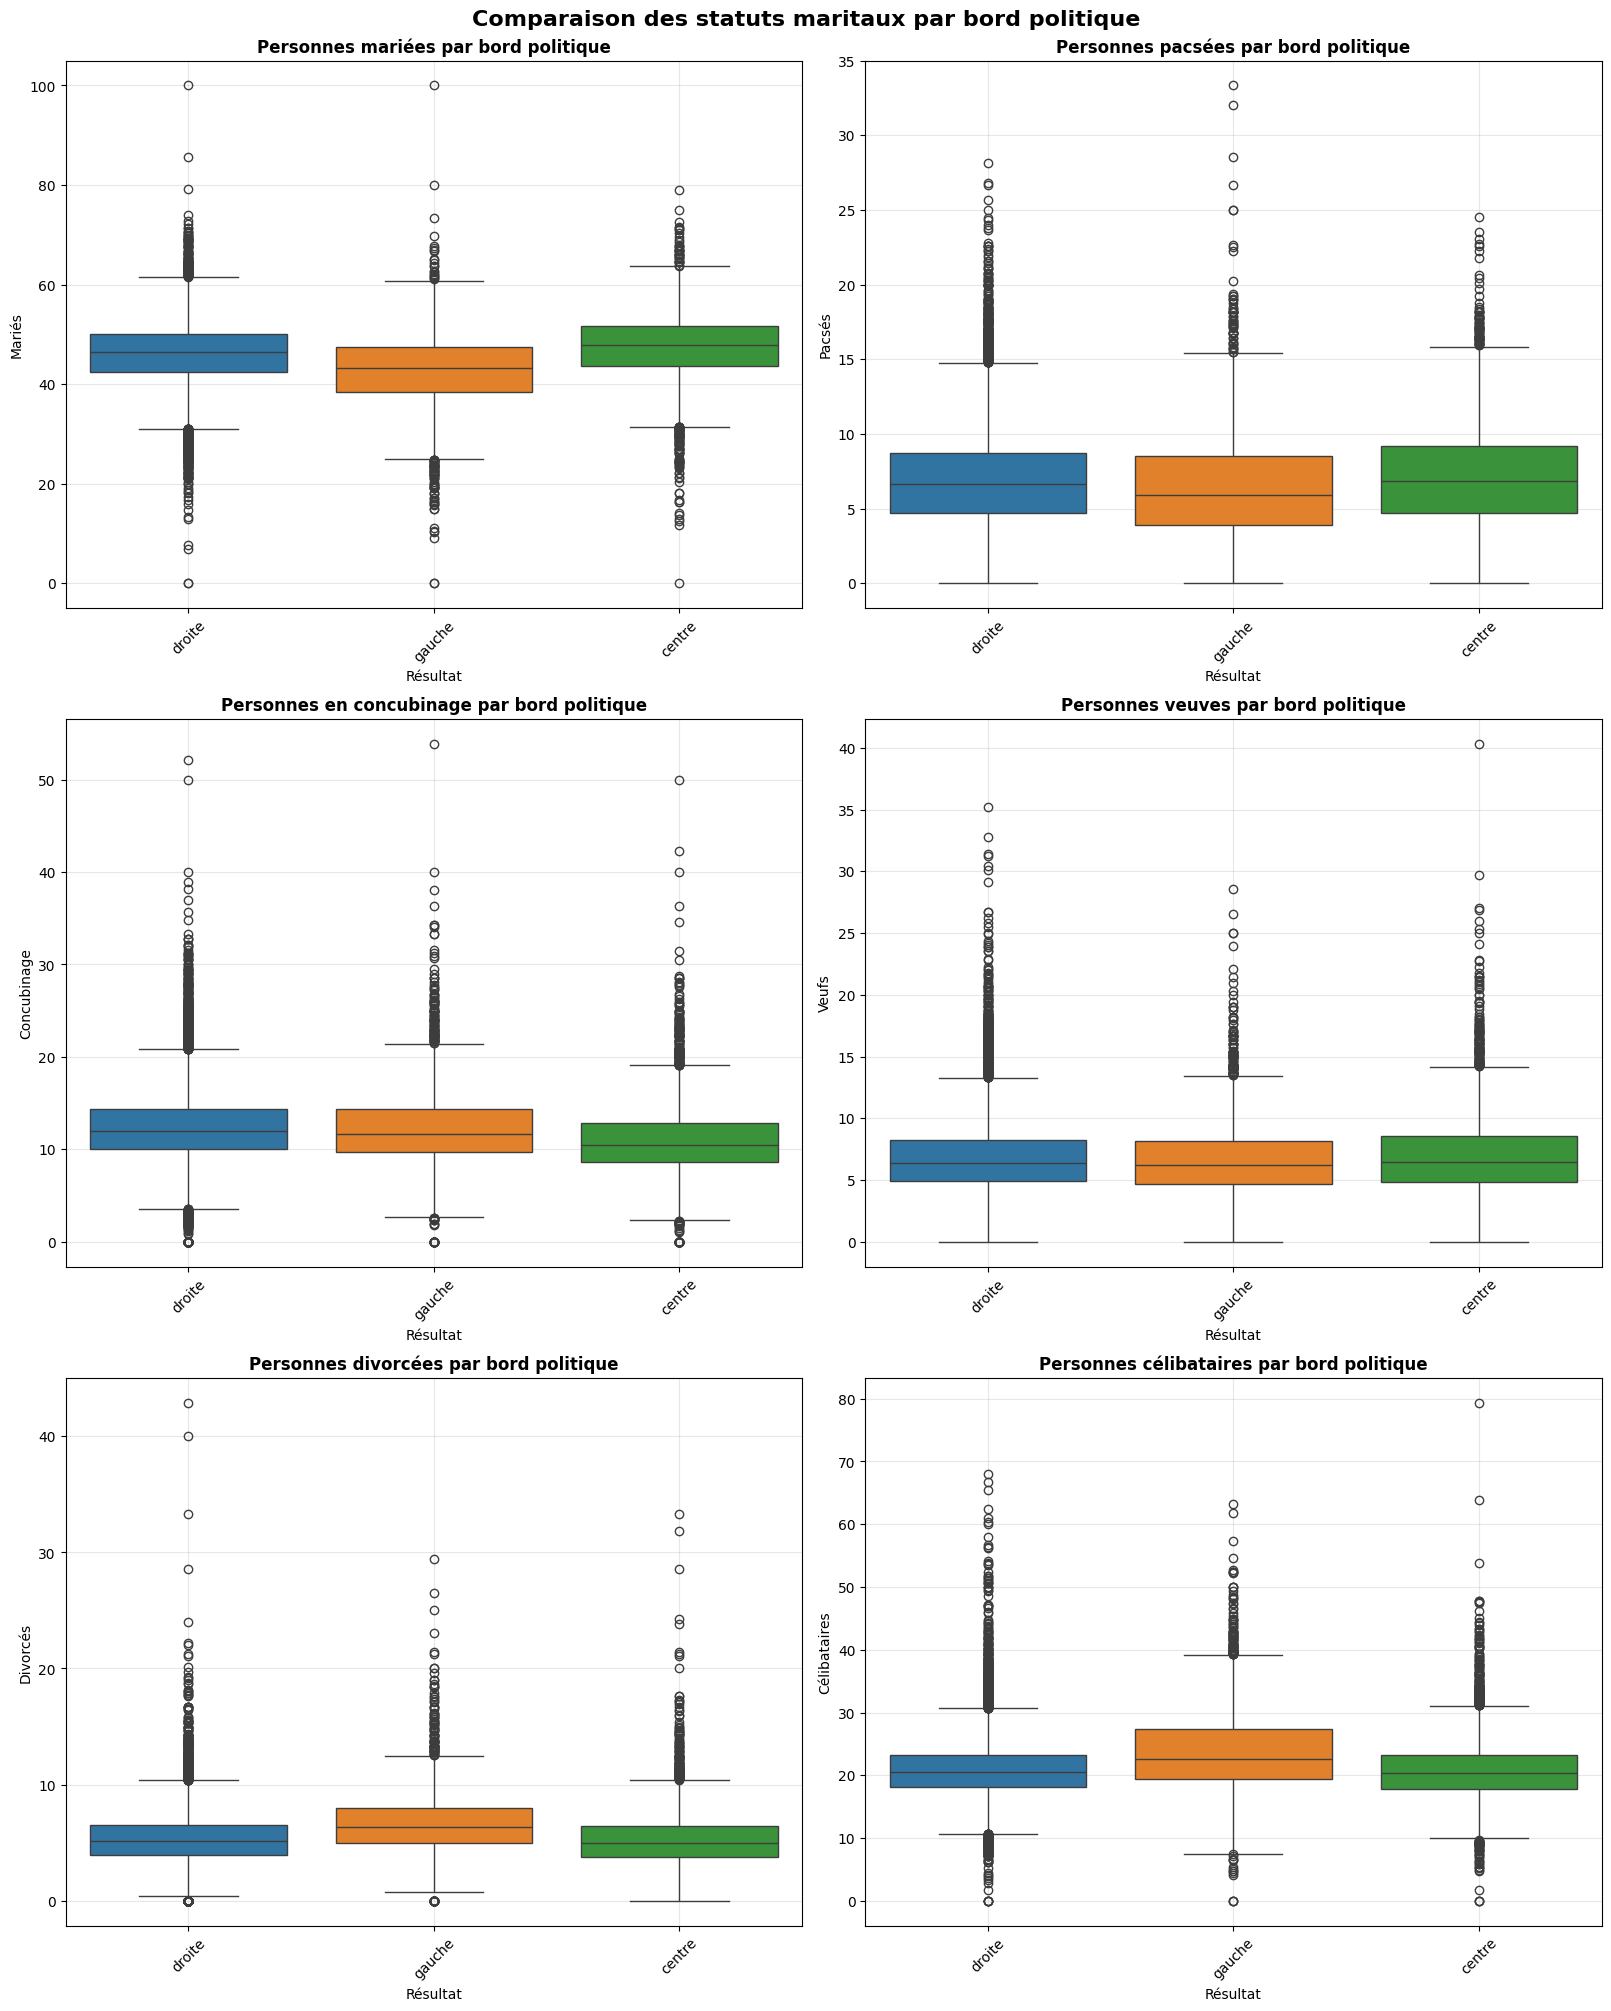

In [35]:
df_conjugality = df[['Résultat', 'Mariés', 'Pacsés', 'Concubinage', 'Veufs', 'Divorcés', 'Célibataires']]

fig, axes = plt.subplots(3, 2, figsize=(16, 20), layout="constrained")
fig.suptitle('Comparaison des statuts maritaux par bord politique', fontsize=16, fontweight='bold')

comparisons = [
    ('Mariés', 'Personnes mariées par bord politique'),
    ('Pacsés', 'Personnes pacsées par bord politique'),
    ('Concubinage', 'Personnes en concubinage par bord politique'),
    ('Veufs', 'Personnes veuves par bord politique'),
    ('Divorcés', 'Personnes divorcées par bord politique'),
    ('Célibataires', 'Personnes célibataires par bord politique')
]

for i, (var, title) in enumerate(comparisons):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    sns.boxplot(data=df_conjugality, x='Résultat', y=var, ax=ax, 
                hue='Résultat', showfliers=True)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Résultat'.title())
    ax.set_ylabel(var.title())
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.show()

- Les personnes célibataires et divorcées votent davantage pour la gauche
- Les personnes mariées votent moins pour la gauche (redondance avec l'observation ci-dessus)
- Les personnes en concubinage votent moins pour le centre

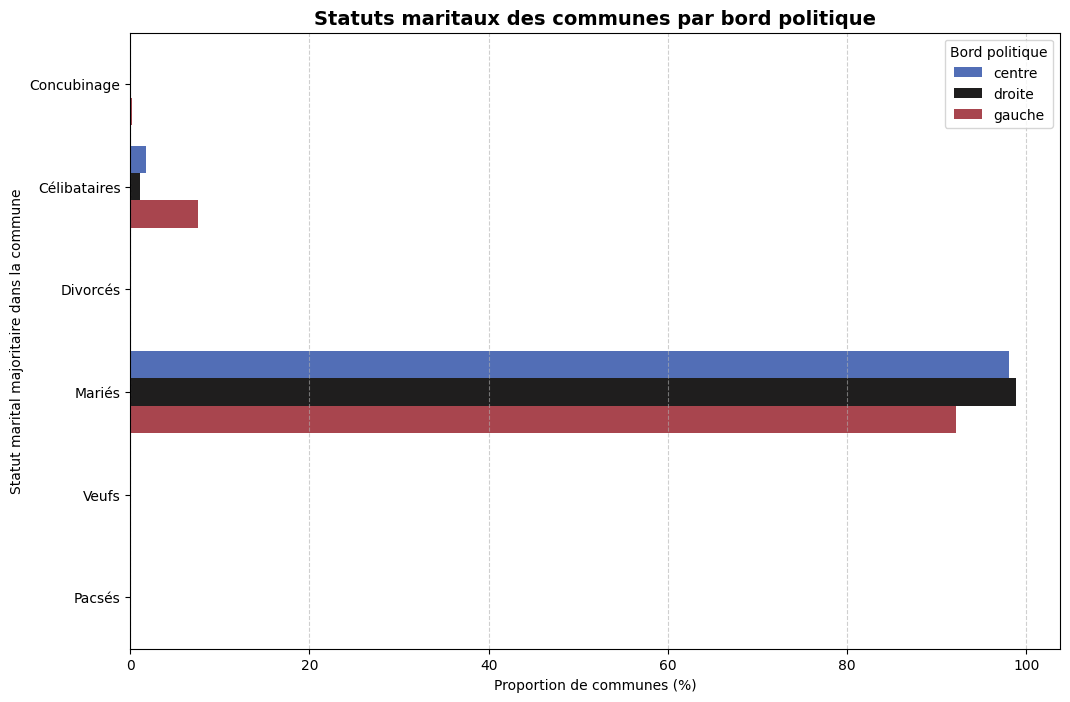

In [ ]:
cols_conju = ['Mariés', 'Pacsés', 'Concubinage', 'Veufs', 'Divorcés', 'Célibataires']
mask = df_conjugality[cols_conju].notna().any(axis=1)
df_conjugality.loc[mask, 'Majorité'] = df_conjugality.loc[mask, cols_conju].idxmax(axis=1)


df_counts_conju = df_conjugality.groupby(['Résultat', 'Majorité']).size().reset_index(name='count')
df_counts_conju['Densité'] = df_counts_conju.groupby('Résultat')['count'].transform(lambda x: x / x.sum() * 100)


plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_counts_conju, 
    y='Majorité',
    x='Densité',
    hue='Résultat',
    palette='icefire'
)

plt.title('Statuts maritaux des communes par bord politique', fontweight='bold', fontsize=14)
plt.xlabel('Proportion de communes (%)')
plt.ylabel('Statut marital majoritaire dans la commune')
plt.legend(title='Bord politique')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()